In [1]:
#Step 1 — Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Step 2 — Load the raw data
df = pd.read_csv('endo_data.csv.xls')
df.head()

,Age,BMI,Cycle_Length,Age_of_Menarche,Dysmenorrhea_Score,Pelvic_Pain_Score,Dyspareunia_Score,Dyschezia_Score,Urinary_Symptoms_Score,Family_History,Infertility_Status,CA_125_Level,CRP_Level,Mental_Health_Score,Endometriosis_Stage
0,43,33.79,38,17,10,0,4,10,0,false,false,1052.771,185.966,0,false
1,36,10.61,45,9,5,10,7,2,7,true,false,124.108,82.589,3,true
2,36,24.58,34,9,4,5,2,10,7,false,true,236.559,0.547,3,false
3,14,12.8,52,9,4,6,5,2,8,false,true,697.311,49.582,2,false
4,53,16.55,32,14,1,7,2,6,4,true,false,150.675,285.178,8,false


In [3]:
# Step 3 — Remove repeated header rows
df = df[df['Age_of_Menarche'] != 'Age_of_Menarche']
df

,Age,BMI,Cycle_Length,Age_of_Menarche,Dysmenorrhea_Score,Pelvic_Pain_Score,Dyspareunia_Score,Dyschezia_Score,Urinary_Symptoms_Score,Family_History,Infertility_Status,CA_125_Level,CRP_Level,Mental_Health_Score,Endometriosis_Stage
0,43,33.79,38,17,10,0,4,10,0,false,false,1052.771,185.966,0,false
1,36,10.61,45,9,5,10,7,2,7,true,false,124.108,82.589,3,true
2,36,24.58,34,9,4,5,2,10,7,false,true,236.559,0.547,3,false
3,14,12.8,52,9,4,6,5,2,8,false,true,697.311,49.582,2,false
4,53,16.55,32,14,1,7,2,6,4,true,false,150.675,285.178,8,false
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
480075,34,28.27022069,28,15,10,0,3,7,4,0,0,NaN,NaN,6,0
480076,20,33.90886561,22,15,3,6,2,4,2,0,0,NaN,NaN,3,0
480077,43,21.97808988,28,11,8,9,4,9,1,0,1,NaN,NaN,9,0
480078,32,19.43459511,21,15,7,4,4,8,9,1,1,NaN,NaN,5,1


In [4]:
# Step 4 — Remove the junk row
df = df.dropna(how='all', subset=df.columns.difference(['Age']))
df

,Age,BMI,Cycle_Length,Age_of_Menarche,Dysmenorrhea_Score,Pelvic_Pain_Score,Dyspareunia_Score,Dyschezia_Score,Urinary_Symptoms_Score,Family_History,Infertility_Status,CA_125_Level,CRP_Level,Mental_Health_Score,Endometriosis_Stage
0,43,33.79,38,17,10,0,4,10,0,false,false,1052.771,185.966,0,false
1,36,10.61,45,9,5,10,7,2,7,true,false,124.108,82.589,3,true
2,36,24.58,34,9,4,5,2,10,7,false,true,236.559,0.547,3,false
3,14,12.8,52,9,4,6,5,2,8,false,true,697.311,49.582,2,false
4,53,16.55,32,14,1,7,2,6,4,true,false,150.675,285.178,8,false
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
480074,18,29.70162296,24,13,7,2,3,0,3,1,0,NaN,NaN,3,1
480075,34,28.27022069,28,15,10,0,3,7,4,0,0,NaN,NaN,6,0
480076,20,33.90886561,22,15,3,6,2,4,2,0,0,NaN,NaN,3,0
480077,43,21.97808988,28,11,8,9,4,9,1,0,1,NaN,NaN,9,0


Drops the one row that was completely blank except for a stray character in Age.

In [5]:
# Step 5 — Convert text to numbers
number_cols = ['Age','BMI','Cycle_Length','Age_of_Menarche','Dysmenorrhea_Score',
               'Pelvic_Pain_Score','Dyspareunia_Score','Dyschezia_Score',
               'Urinary_Symptoms_Score','CA_125_Level','CRP_Level','Mental_Health_Score']
for col in number_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df

,Age,BMI,Cycle_Length,Age_of_Menarche,Dysmenorrhea_Score,Pelvic_Pain_Score,Dyspareunia_Score,Dyschezia_Score,Urinary_Symptoms_Score,Family_History,Infertility_Status,CA_125_Level,CRP_Level,Mental_Health_Score,Endometriosis_Stage
0,43,33.790000,38,17,10,0,4,10,0,false,false,1052.771,185.966,0,false
1,36,10.610000,45,9,5,10,7,2,7,true,false,124.108,82.589,3,true
2,36,24.580000,34,9,4,5,2,10,7,false,true,236.559,0.547,3,false
3,14,12.800000,52,9,4,6,5,2,8,false,true,697.311,49.582,2,false
4,53,16.550000,32,14,1,7,2,6,4,true,false,150.675,285.178,8,false
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
480074,18,29.701623,24,13,7,2,3,0,3,1,0,NaN,NaN,3,1
480075,34,28.270221,28,15,10,0,3,7,4,0,0,NaN,NaN,6,0
480076,20,33.908866,22,15,3,6,2,4,2,0,0,NaN,NaN,3,0
480077,43,21.978090,28,11,8,9,4,9,1,0,1,NaN,NaN,9,0


These columns mixed 'true'/'false' text with '1'/'0' numbers. Standardizes both into clean Python booleans.

In [6]:
# Step 7 — Remove duplicate rows 
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} duplicates -> {len(df)} rows remain")
# Dropped 395000 duplicates -> 85000 rows remain

Dropped 395000 duplicates -> 85000 rows remain


In [7]:
# Step 8 — Check missing values
print(df.isna().sum())

# removing missing values
df = df.dropna(subset=['CA_125_Level', 'CRP_Level'])

Age                          0
BMI                          0
Cycle_Length                 0
Age_of_Menarche              0
Dysmenorrhea_Score           0
Pelvic_Pain_Score            0
Dyspareunia_Score            0
Dyschezia_Score              0
Urinary_Symptoms_Score       0
Family_History               0
Infertility_Status           0
CA_125_Level              5000
CRP_Level                 5000
Mental_Health_Score          0
Endometriosis_Stage          0
dtype: int64


In [8]:
# Step 9 — Summary statistics
print(df[number_cols].describe().T[['min','max','mean']])

                           min       max         mean
Age                     12.000    60.000    35.986250
BMI                     10.000    60.000    34.979636
Cycle_Length            15.000    60.000    37.494700
Age_of_Menarche          8.000    20.000    13.984412
Dysmenorrhea_Score       0.000    10.000     4.997300
Pelvic_Pain_Score        0.000    10.000     4.998725
Dyspareunia_Score        0.000    10.000     4.997250
Dyschezia_Score          0.000    10.000     4.989937
Urinary_Symptoms_Score   0.000    10.000     5.006600
CA_125_Level             0.038  1999.984  1000.583503
CRP_Level                0.006   299.995   150.107607
Mental_Health_Score      0.000    10.000     5.021400


In [9]:
# Step 10 — Compare averages by diagnosis group
print(df.groupby('Endometriosis_Stage')[number_cols].mean().T)

Endometriosis_Stage           false         true
Age                       35.952714    36.019877
BMI                       34.988980    34.970266
Cycle_Length              37.476307    37.513143
Age_of_Menarche           13.971164    13.997697
Dysmenorrhea_Score         4.986169     5.008461
Pelvic_Pain_Score          5.006616     4.990813
Dyspareunia_Score          4.991661     5.002854
Dyschezia_Score            5.000924     4.978922
Urinary_Symptoms_Score     4.987117     5.026135
CA_125_Level            1000.710617  1000.456045
CRP_Level                149.701000   150.515314
Mental_Health_Score        5.020947     5.021855


In [10]:
# Step 11 — Correlation with diagnosis

target = df['Endometriosis_Stage'].replace(
    {'true': True, 'false': False, '1': True, '0': False, True: True, False: False}
).astype(bool).astype(int)

correlations = df[number_cols].corrwith(target)
print(correlations.sort_values(key=abs, ascending=False))

Urinary_Symptoms_Score    0.006174
CRP_Level                 0.004706
Age_of_Menarche           0.003547
Dysmenorrhea_Score        0.003524
Dyschezia_Score          -0.003477
Pelvic_Pain_Score        -0.002490
Age                       0.002380
Dyspareunia_Score         0.001776
Cycle_Length              0.001388
BMI                      -0.000649
CA_125_Level             -0.000221
Mental_Health_Score       0.000143
dtype: float64


In [12]:
# Step 12 — Categorical columns vs. diagnosis
print(pd.crosstab(df['Family_History'], df['Endometriosis_Stage'], normalize='index') * 100)
print(pd.crosstab(df['Infertility_Status'], df['Endometriosis_Stage'], normalize='index') * 100)

Endometriosis_Stage      false       true
Family_History                           
false                50.048768  49.951232
true                 50.086218  49.913782
Endometriosis_Stage      false       true
Infertility_Status                       
false                50.149141  49.850859
true                 49.986286  50.013714


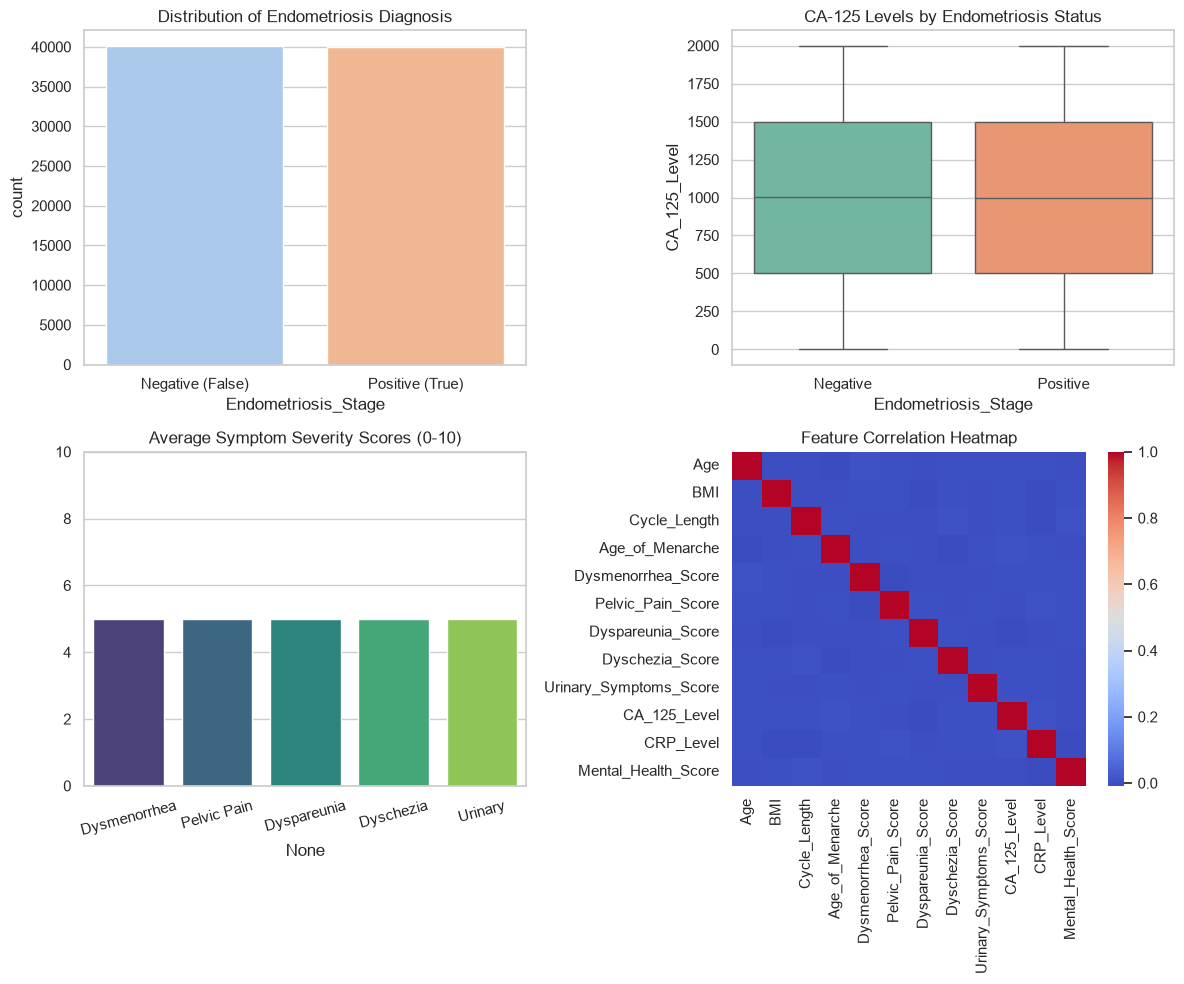

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Top-left: how many diagnosed vs not
sns.countplot(data=df, x='Endometriosis_Stage', hue='Endometriosis_Stage',
              ax=axes[0, 0], palette='pastel', legend=False)
axes[0, 0].set_title('Distribution of Endometriosis Diagnosis')
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(['Negative (False)', 'Positive (True)'])

# Top-right: CA-125 spread by diagnosis
sns.boxplot(data=df, x='Endometriosis_Stage', y='CA_125_Level',
            hue='Endometriosis_Stage', ax=axes[0, 1], palette='Set2', legend=False)
axes[0, 1].set_title('CA-125 Levels by Endometriosis Status')
axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_xticklabels(['Negative', 'Positive'])

# Bottom-left: average symptom scores
pain_cols = ['Dysmenorrhea_Score', 'Pelvic_Pain_Score', 'Dyspareunia_Score',
             'Dyschezia_Score', 'Urinary_Symptoms_Score']
mean_scores = df[pain_cols].mean()
sns.barplot(x=mean_scores.index, y=mean_scores.values, hue=mean_scores.index,
            ax=axes[1, 0], palette='viridis', legend=False)
axes[1, 0].set_title('Average Symptom Severity Scores (0-10)')
axes[1, 0].set_xticks(range(len(pain_cols)))
axes[1, 0].set_xticklabels(['Dysmenorrhea', 'Pelvic Pain', 'Dyspareunia', 'Dyschezia', 'Urinary'], rotation=15)
axes[1, 0].set_ylim(0, 10)

# Bottom-right: correlation between every numeric pair
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, ax=axes[1, 1], cmap='coolwarm', annot=False)
axes[1, 1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

In [ ]:
# save files 
df.to_csv('endo_data_cleaned.csv', index=False)